# Analiza podatkov Tour de France 2026

V projektu analiziramo podatke o Tour de France 2026, pridobljene s spletne strani ProCyclingStats.

Podatki so shranjeni v csv datotekah:
+ "tour_2026_etape.csv"-splošni podatki o vsaki etapi
+ "tour_2026_koleasrji.csv"-potaki o kolesarjih udeleženih na touru 
+ "tour_2026_rezultati.csv"-končni časi vsakega kolesarja na etapi
+ "tour_2026_razsirjeno.csv"-združena datoteka dosedanjih podatkov
+ "tour_2026_breakaway.csv"-podatki o ubežnikih vsake etape

V zvezku pogledamo:
1. Profil celotnega Toura
2. Hitrost zmagovalca skozi Tour
3. Hitrost v odvisnosti od težavnosti etape
4. Starost udeležencev
5. Razvoj vrstnega reda najboljših
6. Zaostanki najboljših po vsaki etapi
7. Porazdelitev zaostankov v etapi
8. Koliko kolesarjev je še ostalo v dirki
9. Velikost pobegov
10. Kilometri v pobegu
11. Zmage glede na tip kolesarja
12. Specializacija in končni rezultat

## Uvoz knjižnic in podatkov

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

etape = pd.read_csv("data/tour_2026_etape.csv")
rezultati = pd.read_csv("data/tour_2026_rezultati.csv")
kolesarji = pd.read_csv("data/tour_2026_kolesarji.csv")
pobegi = pd.read_csv("data/tour_2026_breakaway.csv")

print("Etape:", len(etape))
print("Kolesarji:", len(kolesarji))
print("Rezultati:", len(rezultati))
print("Zapisi o pobegih:", len(pobegi))

Etape: 21
Kolesarji: 184
Rezultati: 3637
Zapisi o pobegih: 475


## 1. Profil celotnega Toura

Najprej pogledamo, koliko višinskih metrov je imela vsaka etapa. To nam pokaže porazdelitev lažjih in režjih etap skozi tekmovanje.

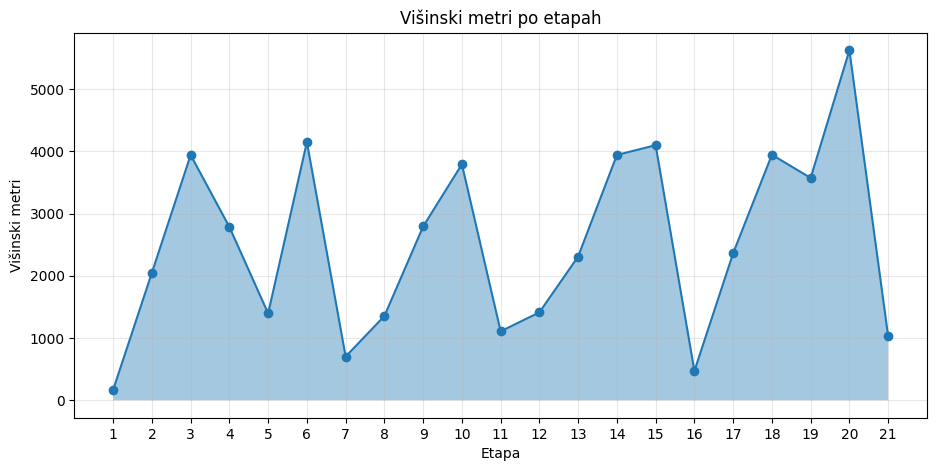

In [2]:
plt.figure(figsize=(11, 5))
plt.fill_between(etape["stage"], etape["vertical_meters"], alpha=0.4)
plt.plot(etape["stage"], etape["vertical_meters"], marker="o")
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Višinski metri")
plt.title("Višinski metri po etapah")
plt.grid(alpha=0.3)
plt.show()

Vidimo, da je bilo letos že skozi prva dva tedna veliko zahtevnih etap, kar je v primerjavi z ostalimi trotedenskimi dirkami dokaj nenavadno. Po pričakovanjih pa so bile najtežje etape v zadnjem tednu.

## 2. Hitrost zmagovalca skozi Tour

Oglejmo si, kakšna je bila povprečna hitrost zmagovalca vsake etape.

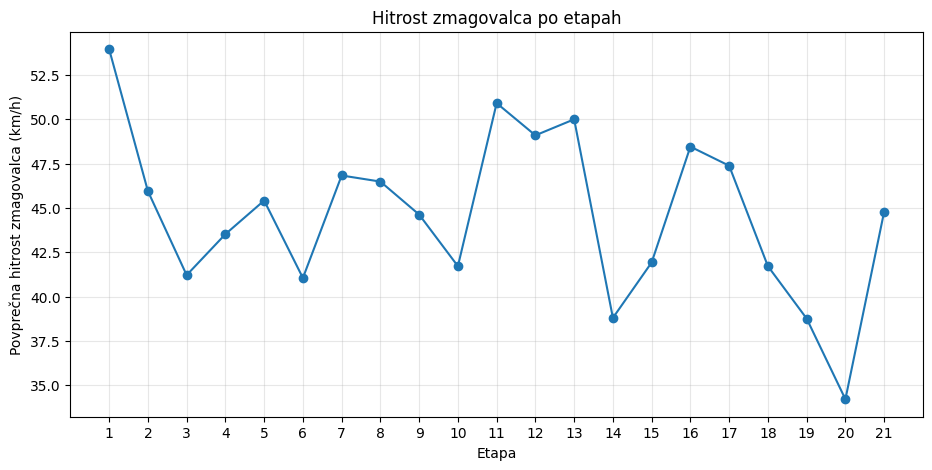

In [3]:
plt.figure(figsize=(11, 5))
plt.plot(etape["stage"], etape["avg_speed_winner_kmh"], marker="o")
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Povprečna hitrost zmagovalca (km/h)")
plt.title("Hitrost zmagovalca po etapah")
plt.grid(alpha=0.3)
plt.show()

## 3. Hitrost v odvisnosti od težavnosti etape

`profile_score` je ocena zahtevnosti profila etape. S scatter plotom preverimo povezavo med zahtevnostjo in povprečno hitrostjo zmagovalca.

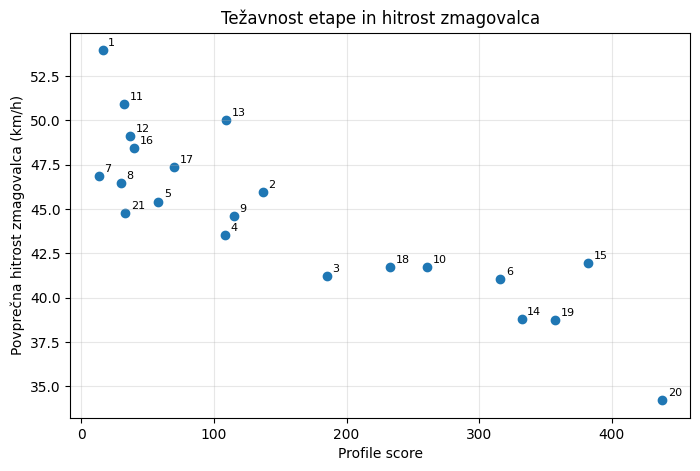

Korelacija: -0.86


In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(etape["profile_score"], etape["avg_speed_winner_kmh"])

for _, etapa in etape.iterrows():
    plt.annotate(
        int(etapa["stage"]),
        (etapa["profile_score"], etapa["avg_speed_winner_kmh"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("Profile score")
plt.ylabel("Povprečna hitrost zmagovalca (km/h)")
plt.title("Težavnost etape in hitrost zmagovalca")
plt.grid(alpha=0.3)
plt.show()

korelacija = etape["profile_score"].corr(etape["avg_speed_winner_kmh"])
print(f"Korelacija: {korelacija:.2f}")

## 4. Starost udeležencev

Histogram pokaže porazdelitev starosti kolesarjev na startu Toura.

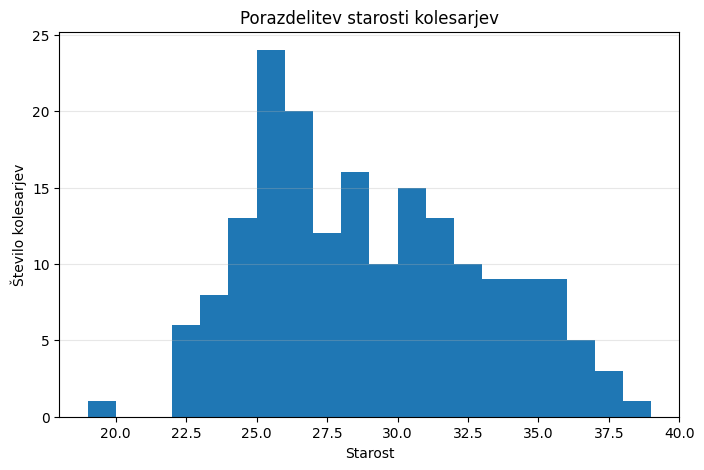

Povprečna starost: 28.5 let
Najmlajši: 19 let
Najstarejši: 38 let


In [5]:
starosti = rezultati.drop_duplicates("rider_url")["age"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(
    starosti,
    bins=range(int(starosti.min()), int(starosti.max()) + 2),
)
plt.xlabel("Starost")
plt.ylabel("Število kolesarjev")
plt.title("Porazdelitev starosti kolesarjev")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Povprečna starost: {starosti.mean():.1f} let")
print(f"Najmlajši: {int(starosti.min())} let")
print(f"Najstarejši: {int(starosti.max())} let")

## 5. Razvoj vrstnega reda najboljših

Izberemo končnih pet najboljših kolesarjev in pogledamo njihovo mesto v skupnem seštevku po vsaki etapi.

Os je obrnjena, zato je 1. mesto na vrhu.

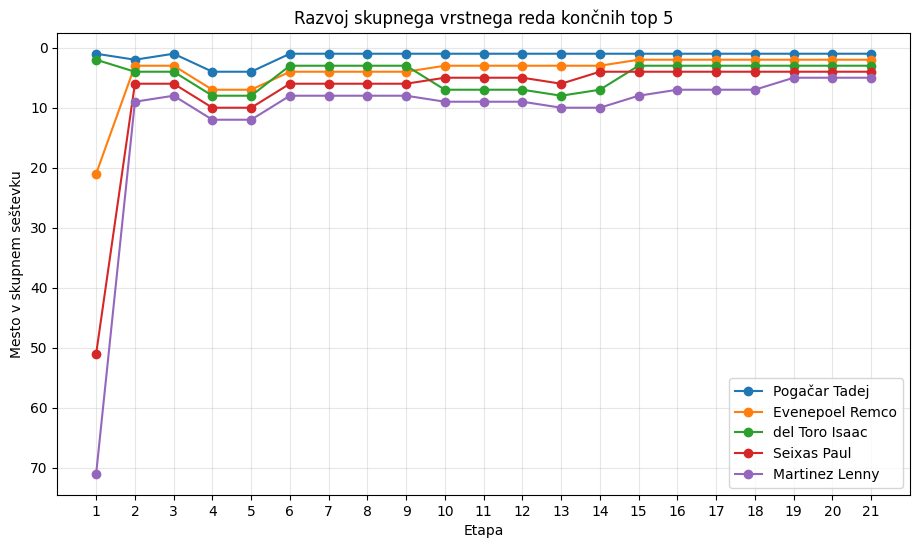

In [15]:
zadnja_etapa = rezultati["stage"].max()

koncni_vrstni_red = (
    rezultati[rezultati["stage"] == zadnja_etapa]
    .dropna(subset=["gc_position"])
    .sort_values("gc_position")
)

top5_url = koncni_vrstni_red.head(5)["rider_url"]

plt.figure(figsize=(11, 6))

for rider_url in top5_url:
    podatki = rezultati[rezultati["rider_url"] == rider_url].sort_values("stage")
    ime = podatki["rider"].iloc[0]
    plt.plot(
        podatki["stage"],
        podatki["gc_position"],
        marker="o",
        label=ime,
    )

plt.gca().invert_yaxis()
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Mesto v skupnem seštevku")
plt.title("Razvoj skupnega vrstnega reda končnih top 5")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Zaostanki najboljših po vsaki etapi

Samo mesto v razvrstitvi ne pove, kako velika je bila razlika. Zato za istih pet kolesarjev prikažemo še njihov časovni zaostanek za vodilnim.

Za prvo etapo podatek o časovnem zaostanku v podatkih ni zapisan, zato graf začne uporabljati zaostanke tam, kjer so na voljo.

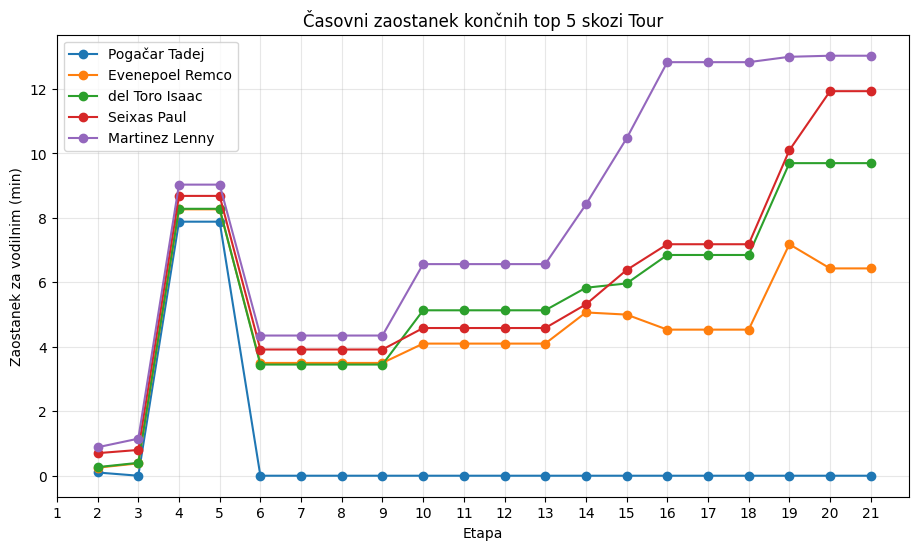

In [7]:
plt.figure(figsize=(11, 6))

for rider_url in top5_url:
    podatki = rezultati[
        (rezultati["rider_url"] == rider_url)
        & rezultati["gc_timelag_seconds"].notna()
    ].sort_values("stage").copy()

    ime = podatki["rider"].iloc[0]
    podatki["zaostanek_min"] = podatki["gc_timelag_seconds"] / 60

    plt.plot(
        podatki["stage"],
        podatki["zaostanek_min"],
        marker="o",
        label=ime,
    )

plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Zaostanek za vodilnim (min)")
plt.title("Časovni zaostanek končnih top 5 skozi Tour")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Porazdelitev zaostankov v etapi

Za vsako etapo pogledamo porazdelitev časovnih zaostankov vseh kolesarjev, ki so etapo končali.

Boxplot je uporaben, ker ne pokaže samo enega povprečja, ampak celotno razpršenost rezultatov. Zaradi preglednosti ne rišemo najbolj skrajnih osamelcev (`showfliers=False`).

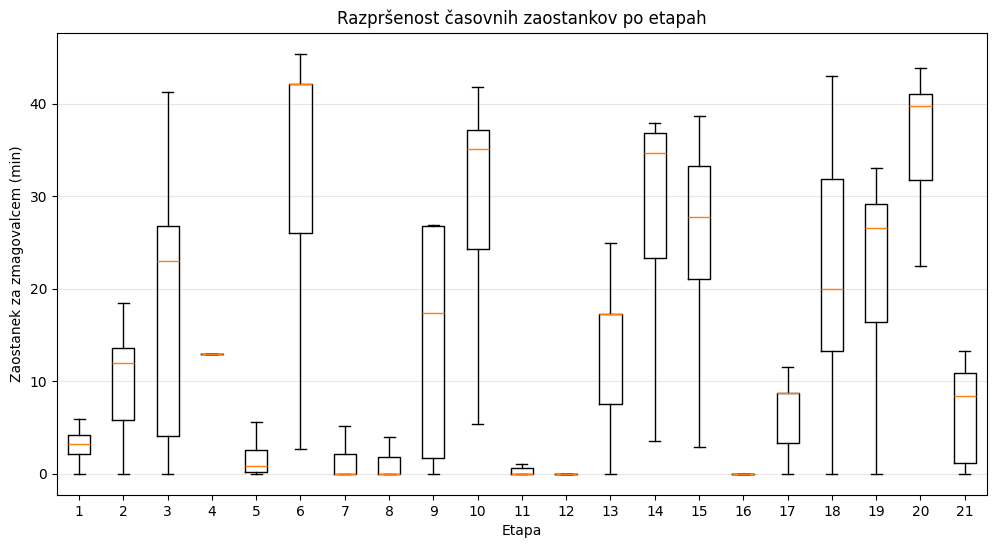

In [8]:
zaostanki_po_etapah = []

for etapa in range(1, 22):
    zaostanki = (
        rezultati[
            (rezultati["stage"] == etapa)
            & (rezultati["status"] == "finished")
        ]["stage_gap_seconds"]
        .dropna()
        / 60
    )
    zaostanki_po_etapah.append(zaostanki)

plt.figure(figsize=(12, 6))
plt.boxplot(
    zaostanki_po_etapah,
    tick_labels=range(1, 22),
    showfliers=False,
)
plt.xlabel("Etapa")
plt.ylabel("Zaostanek za zmagovalcem (min)")
plt.title("Razpršenost časovnih zaostankov po etapah")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Koliko kolesarjev je še ostalo v dirki

Število kolesarjev, ki uspešno končajo posamezno etapo, skozi Tour pada. Stopničasti graf je za tak podatek bolj naraven kot navaden stolpčni graf.

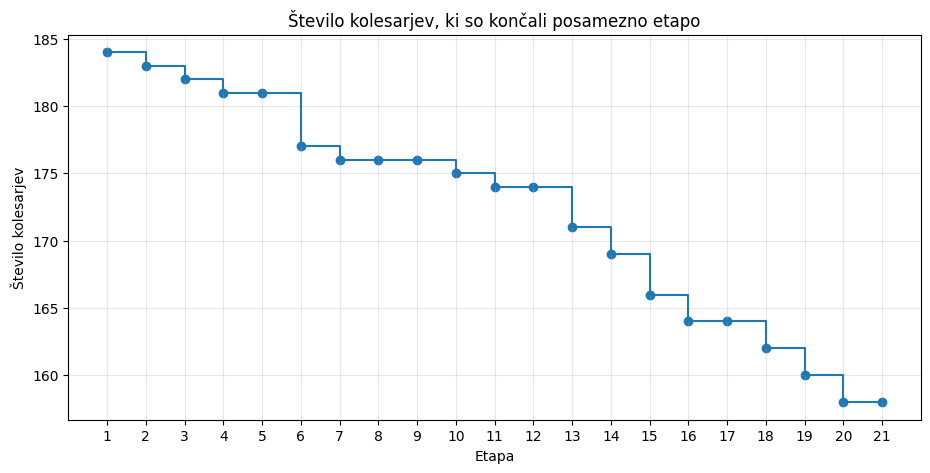

1. etapa: 184
21. etapa: 158
Razlika: 26


In [9]:
ostali = (
    rezultati[rezultati["status"] == "finished"]
    .groupby("stage")
    .size()
)

plt.figure(figsize=(11, 5))
plt.step(ostali.index, ostali.values, where="post")
plt.scatter(ostali.index, ostali.values)
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Število kolesarjev")
plt.title("Število kolesarjev, ki so končali posamezno etapo")
plt.grid(alpha=0.3)
plt.show()

print("1. etapa:", ostali.iloc[0])
print("21. etapa:", ostali.iloc[-1])
print("Razlika:", ostali.iloc[0] - ostali.iloc[-1])

## 9. Velikost pobegov

Za vsako etapo preštejemo število različnih kolesarjev, ki so bili zabeleženi v pobegu. Stem plot lepo poudari posamezne etape z zelo velikimi pobegi.

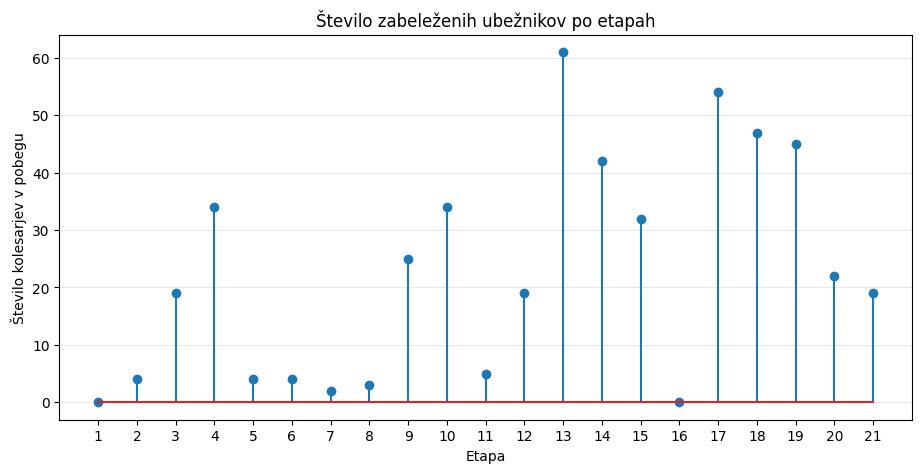

In [10]:
stevilo_ubeznikov = (
    pobegi.groupby("stage")["rider_url"]
    .nunique()
    .reindex(range(1, 22), fill_value=0)
)

plt.figure(figsize=(11, 5))
plt.stem(stevilo_ubeznikov.index, stevilo_ubeznikov.values)
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Število kolesarjev v pobegu")
plt.title("Število zabeleženih ubežnikov po etapah")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 10. Kilometri v pobegu

Preštevanje kilometrov v pobegu postane bolj zanimivo, če ne pogledamo samo končnega seštevka, ampak kako so najbolj napadalni kolesarji kilometre nabirali skozi ves Tour.

Najprej poiščemo pet kolesarjev z največ skupnimi kilometri pred glavnino, nato pa za vsakega narišemo kumulativni seštevek.

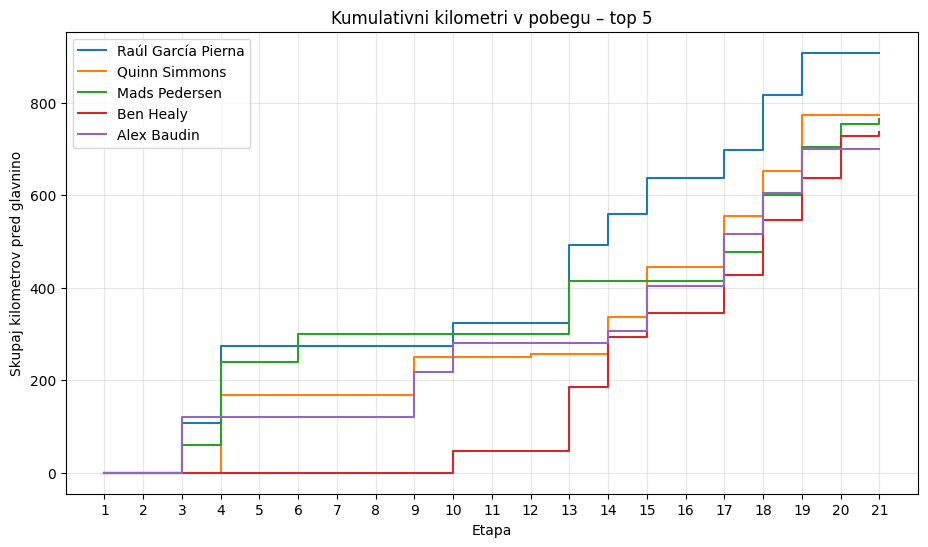

rider_url                                                 rider             
https://www.procyclingstats.com/rider/raul-garcia-pierna  Raúl García Pierna    908.0
https://www.procyclingstats.com/rider/quinn-simmons       Quinn Simmons         773.0
https://www.procyclingstats.com/rider/mads-pedersen       Mads Pedersen         765.0
https://www.procyclingstats.com/rider/ben-healy           Ben Healy             737.0
https://www.procyclingstats.com/rider/alex-baudin         Alex Baudin           699.0
Name: km_before_peloton, dtype: float64

In [11]:
pobegi_z_imeni = pobegi.merge(
    kolesarji[["rider_url", "rider"]],
    on="rider_url",
    how="left",
    suffixes=("_pcs", ""),
)

pobegi_po_etapah = (
    pobegi_z_imeni.groupby(
        ["rider_url", "rider", "stage"],
        as_index=False,
    )["km_before_peloton"]
    .sum()
)

najvec_km = (
    pobegi_po_etapah.groupby(["rider_url", "rider"])["km_before_peloton"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(11, 6))

for rider_url, ime in najvec_km.index:
    podatki = (
        pobegi_po_etapah[
            pobegi_po_etapah["rider_url"] == rider_url
        ]
        .set_index("stage")["km_before_peloton"]
        .reindex(range(1, 22), fill_value=0)
        .cumsum()
    )

    plt.step(
        podatki.index,
        podatki.values,
        where="post",
        label=ime,
    )

plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Skupaj kilometrov pred glavnino")
plt.title("Kumulativni kilometri v pobegu – top 5")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

najvec_km

## 11. Zmage glede na tip kolesarja

Namesto navadnega preštevanja zmag pogledamo, kako so se etapne zmage različnih specializacij nabirale skozi Tour.

Graf je kumulativen: vrednost se poveča vsakič, ko kolesar določene specializacije zmaga etapo.

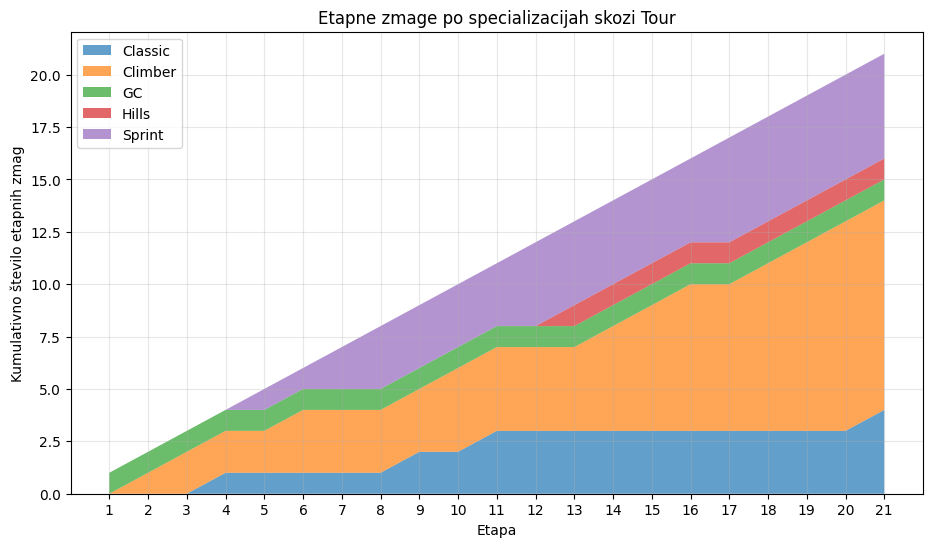

In [12]:
zmagovalci = rezultati[
    (rezultati["rank"] == 1)
    & (rezultati["status"] == "finished")
][["stage", "rider", "specialty"]]

zmage_po_tipih = pd.crosstab(
    zmagovalci["stage"],
    zmagovalci["specialty"],
)

zmage_po_tipih = (
    zmage_po_tipih
    .reindex(range(1, 22), fill_value=0)
    .cumsum()
)

plt.figure(figsize=(11, 6))
plt.stackplot(
    zmage_po_tipih.index,
    *[zmage_po_tipih[stolpec] for stolpec in zmage_po_tipih.columns],
    labels=zmage_po_tipih.columns,
    alpha=0.7,
)
plt.xticks(range(1, 22))
plt.xlabel("Etapa")
plt.ylabel("Kumulativno število etapnih zmag")
plt.title("Etapne zmage po specializacijah skozi Tour")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

## 12. Specializacija in končni rezultat

Za konec primerjamo končne uvrstitve različnih tipov kolesarjev.

Manjša številka pomeni boljšo končno uvrstitev.

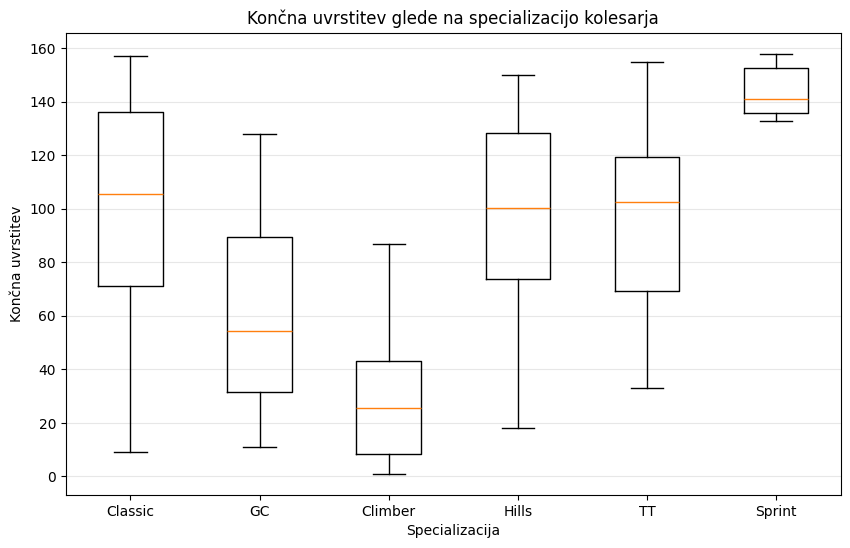

In [13]:
koncni = rezultati[
    (rezultati["stage"] == zadnja_etapa)
    & rezultati["gc_position"].notna()
    & rezultati["specialty"].notna()
].copy()

najpogostejsi_tipi = (
    koncni["specialty"]
    .value_counts()
    .head(6)
    .index
)

podatki_za_boxplot = [
    koncni[koncni["specialty"] == tip]["gc_position"]
    for tip in najpogostejsi_tipi
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    podatki_za_boxplot,
    tick_labels=najpogostejsi_tipi,
    showfliers=False,
)
plt.xlabel("Specializacija")
plt.ylabel("Končna uvrstitev")
plt.title("Končna uvrstitev glede na specializacijo kolesarja")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Zaključek

Grafi pokažejo več različnih vidikov iste dirke:

- kako se zahtevnost etap spreminja skozi Tour,
- kako zahtevnost vpliva na hitrost,
- kako se je razvijal boj za skupno zmago,
- katere etape so ustvarile največje časovne razlike,
- kako so kolesarji postopoma odpadali iz dirke,
- kdaj so nastajali največji pobegi,
- kateri kolesarji so bili najaktivnejši v pobegih,
- kako se različne specializacije kolesarjev kažejo pri etapnih zmagah in končni razvrstitvi.

Analiza uporablja predvsem osnovne operacije `pandas` (`groupby`, `merge`, filtriranje, `crosstab`, `cumsum`) ter različne možnosti knjižnice `matplotlib`.